# Google Play Store Apps Analysis

## Problem Statement
Analyze Google Play Store apps dataset to identify factors contributing to app success, user preferences, category performance, and business opportunities.

# Objectives

- Understand app ratings and user satisfaction
- Identify top performing categories
- Analyze installs and reviews
- Study impact of size and price
- Generate business recommendations

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)  

In [22]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [23]:
df.shape

(10841, 13)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [25]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


### Observation

- Dataset contains 10481 rows and 13 columns.
- Numerical and categorical features are present.
- Rating, Reviews, Installs, Price and Size are important variables.

In [26]:
# Data Cleaning and Preprocessing

In [27]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [28]:
df.duplicated().sum()

483

In [29]:
#removing deuplicates values
df.drop_duplicates(inplace=True)

In [30]:
df.duplicated().sum() 
#now duplicates records removed and having 0 duplicates

0

### Observation

483 duplicate records were identified and removed from the dataset to improve data quality and avoid biased analysis.

In [31]:
#Cleaning Reviews column
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [32]:
#cleaning Installs column
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [33]:
#cleaning Price column
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [34]:
df.drop(10472, inplace=True)

In [35]:
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

In [36]:
df['Last Updated'].head()

0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[ns]

# Exploratory Data Analysis

In [37]:
# Average App Rating
df['Rating'].mean()

4.187876743139902

Average rating of apps is 4.1.

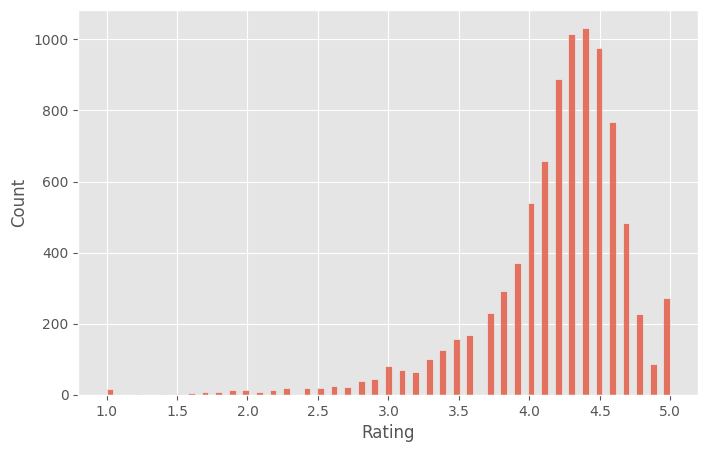

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'])
plt.show()

### Observation

- Most app ratings are concentrated between 4.0 and 4.5.
- Very few apps have extremely low ratings.
- Overall, the Play Store contains a large number of highly rated applications.

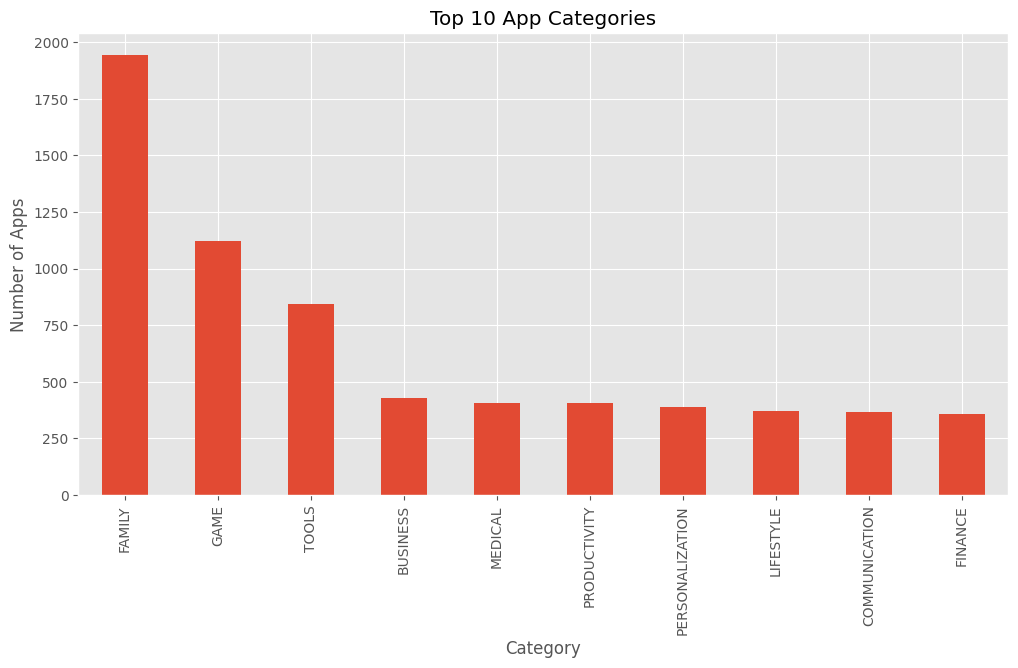

In [39]:
# category distribution
plt.figure(figsize=(12,6))
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.show()

### Observation

- Family category contains the highest number of apps.
- Game and Tools categories also have a significant presence.
- These categories indicate high competition in the Play Store.

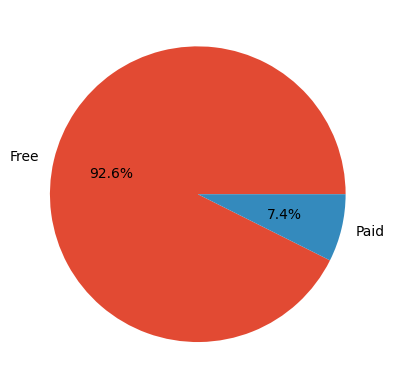

In [40]:
#Free vs Paid Apps
df['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.show()

### Observation

- Free apps dominate the Play Store ecosystem.
- Paid apps represent only a small proportion of total apps.
- Freemium business models appear more common.

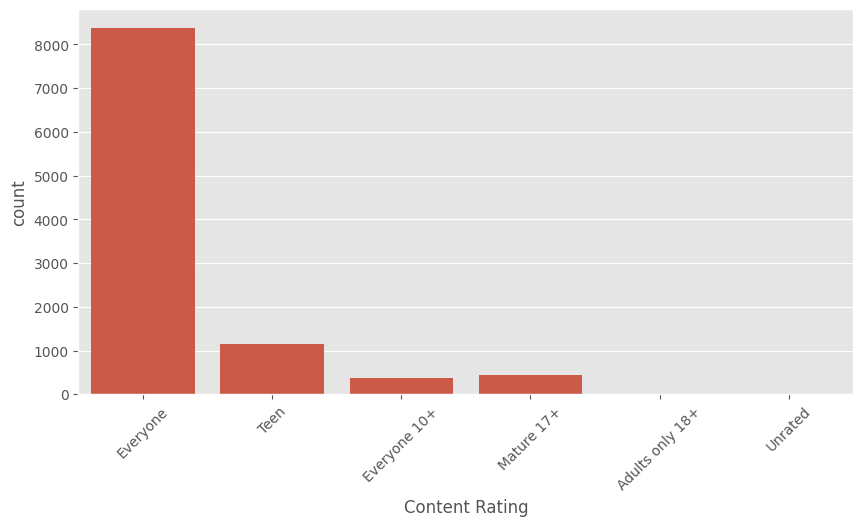

In [41]:
#content ratting distribution
plt.figure(figsize=(10,5))
sns.countplot(
    x='Content Rating',
    data=df
)
plt.xticks(rotation=45)
plt.show()

### Observation

- Most apps target the Everyone category.
- Relatively fewer apps are designed for mature audiences.

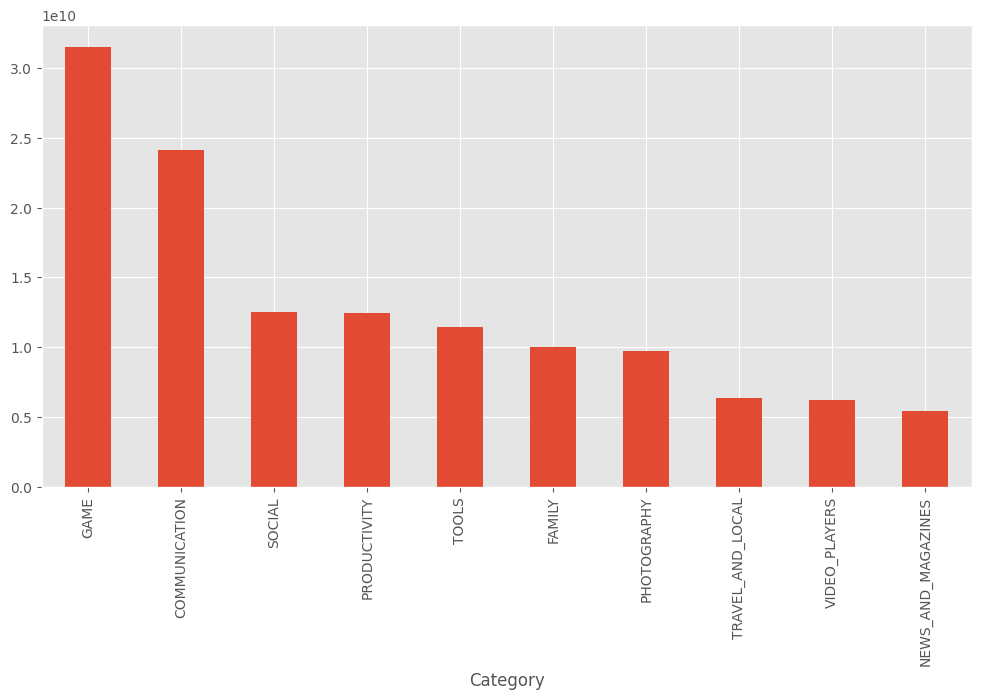

In [42]:
#Top Category By Installs
category_installs = (
    df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
category_installs.plot(kind='bar')
plt.show()

### Observation

- Communication, Tools and Social categories attract the highest installs.
- These categories show strong market demand.

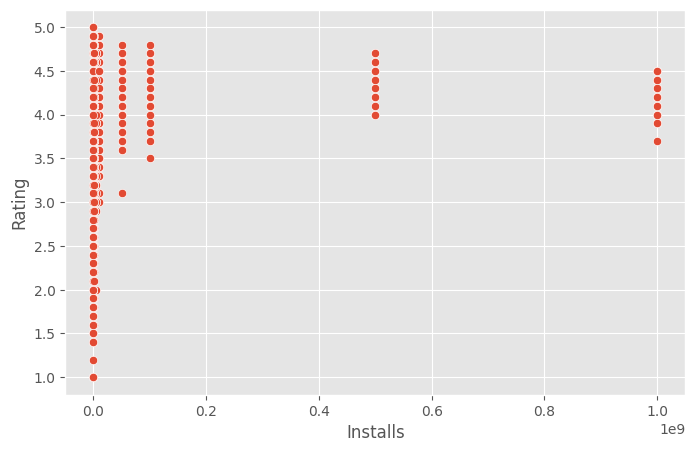

In [44]:
#Rating Vs Installs
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Installs',
    y='Rating',
    data=df
)
plt.show()

### Observation

- Higher installs do not always guarantee higher ratings.
- Some highly installed apps maintain excellent ratings.

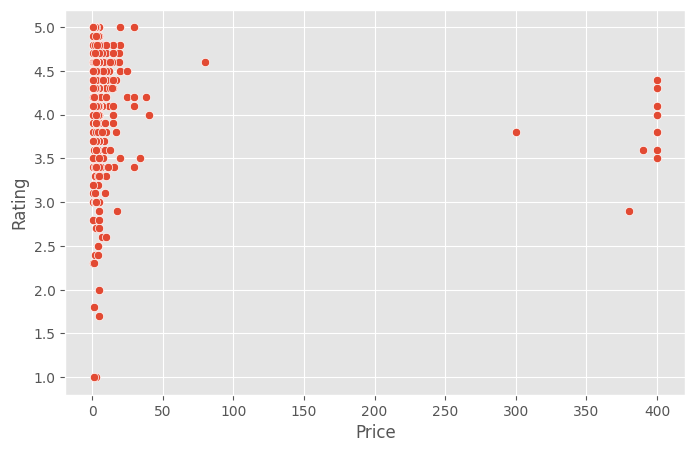

In [45]:
#Price vs Ratting
paid_apps = df[df['Type'] == 'Paid']

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Price',
    y='Rating',
    data=paid_apps
)
plt.show()

### Observation

- No strong relationship is observed between price and rating.
- Expensive apps do not necessarily receive better ratings.

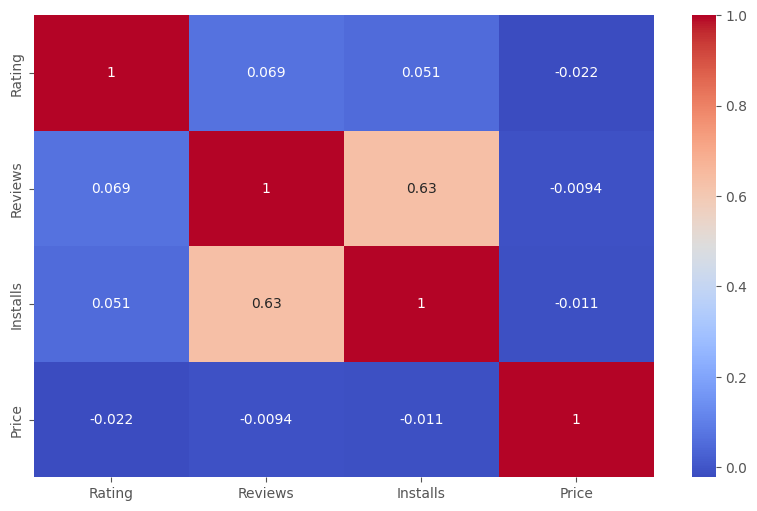

In [46]:
#Correlation heatmap
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

### Observation

- Reviews and Installs show strong positive correlation.
- User engagement is closely linked to app popularity.

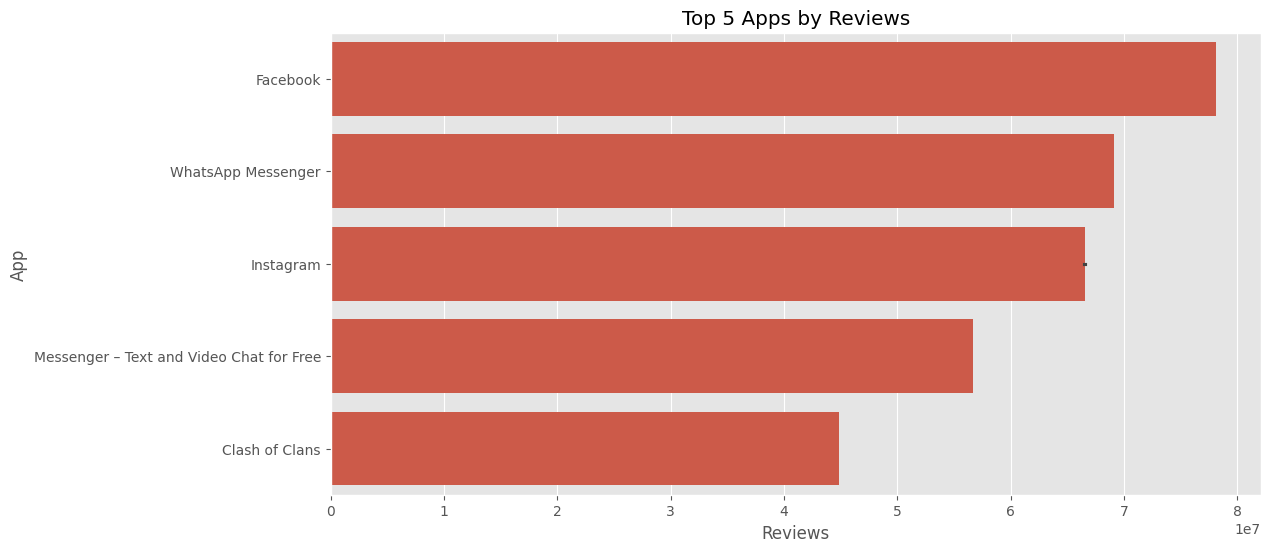

In [49]:
#Top 5 APPS BY REVIEWS
top_reviews = df.nlargest(10, 'Reviews')

plt.figure(figsize=(12,6))
sns.barplot(
    x='Reviews',
    y='App',
    data=top_reviews
)
plt.title('Top 5 Apps by Reviews')
plt.show()

- A small number of apps receive a disproportionately large number of reviews.
- Popular apps generate significantly higher user engagement.

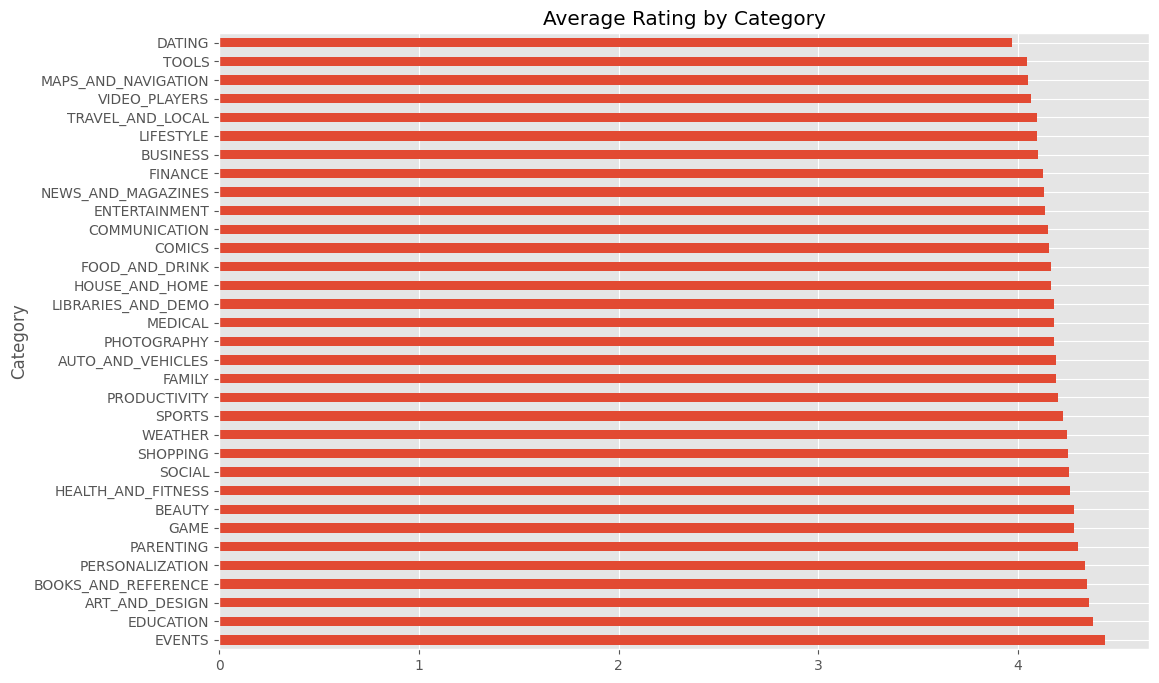

In [50]:
#avg rating by category
avg_rating = (
    df.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
avg_rating.plot(kind='barh')
plt.title('Average Rating by Category')
plt.show()

- Some categories consistently receive higher ratings.
- Users appear more satisfied with apps in these categories.

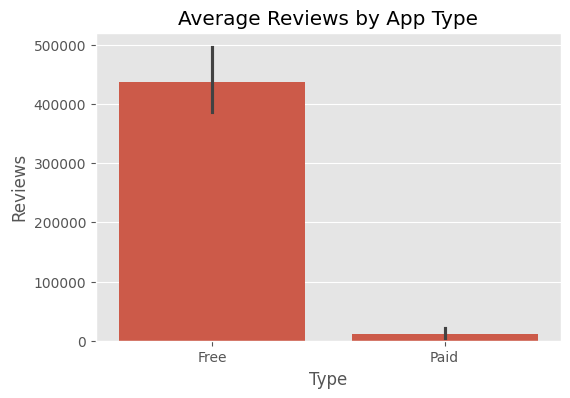

In [51]:
# avg. reviews by free vs paid apps
plt.figure(figsize=(6,4))
sns.barplot(
    x='Type',
    y='Reviews',
    data=df
)
plt.title('Average Reviews by App Type')
plt.show()

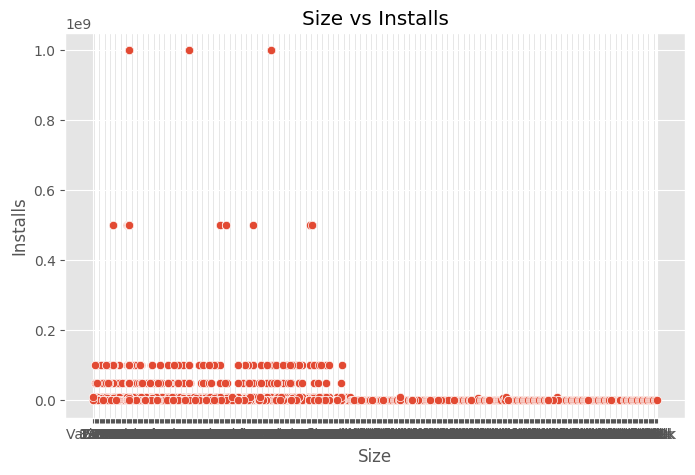

In [52]:
#app size vs installs
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Size',
    y='Installs',
    data=df
)
plt.title('Size vs Installs')
plt.show()

- No strong relationship exists between app size and installs.
- Both small and large apps can achieve high popularity.

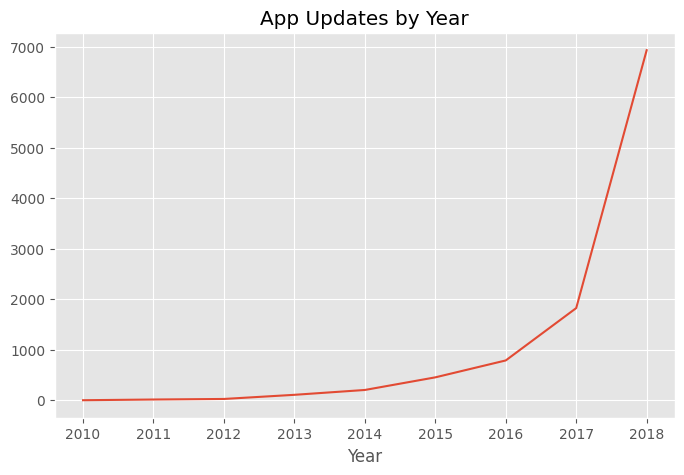

In [54]:
#updated by year
df['Year'] = df['Last Updated'].dt.year

plt.figure(figsize=(8,5))
df['Year'].value_counts().sort_index().plot(kind='line')
plt.title('App Updates by Year')
plt.show()

# Business Insights

1. Most apps maintain ratings above 4.0, indicating generally positive user satisfaction.

2. Free applications dominate the Google Play Store ecosystem.

3. Communication, Social and Tools categories generate the highest install volumes.

4. Reviews and installs show a strong positive relationship.

5. Higher prices do not guarantee higher ratings.

6. Regularly updated apps tend to remain competitive.

7. User engagement is a major indicator of app success.

# Recommendations

1. Focus development efforts on high-performing categories.

2. Encourage user reviews through engagement campaigns.

3. Maintain frequent app updates.

4. Use freemium models where appropriate.

5. Optimize app size without compromising functionality.

# Conclusion

This analysis explored various factors influencing app success on the Google Play Store. Ratings, reviews, installs, category selection, and update frequency were identified as key performance indicators. Free apps dominate the market, while user engagement strongly correlates with app popularity. The findings can help developers and business teams make data-driven decisions to improve app performance and user satisfaction.